# naitzat2020 — Naitzat et al. (2020) Topology of DNNs

Geodesic kNN PH per layer.  Betti numbers *decrease* with depth as the network simplifies input topology.


## What the paper does

The paper asks what a ReLU network *does to the shape of the data*. It feeds a topologically non-trivial dataset (e.g. entangled tori, linked rings) through the network and, at each layer, builds a **kNN graph** of the activations and computes its **geodesic** (shortest-path) distance matrix, then runs Vietoris–Rips persistent homology to read off the Betti numbers `β0` (components) and `β1` (loops).

**Methodology:** per-layer activations → kNN geodesic distance → VR PH (`H0`,`H1`) → Betti numbers per layer.

**Expected result:** `β0` and `β1` *decrease monotonically with depth* — a well-trained network progressively simplifies the data's topology, collapsing it toward linearly separable blobs by the final hidden layer (their Fig. 11 bar chart, reproduced below).


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2004.06093](https://arxiv.org/abs/2004.06093)
- **Venue:** JMLR 2020
- **Datasets used:** Synthetic 2-D / 3-D toy manifolds (entangled tori, linked rings, annuli) designed to have known Betti numbers.
- **Models used:** Small fully-connected ReLU/tanh networks of varying depth.
- **Headline result to aim for:** Betti_0 and Betti_1 decrease monotonically with layer index, hitting their trained-class baseline by the final hidden layer.  Their Fig. 11 is the bar chart we now have.
- **Reference code:** no public repo found in web search — check paper supplementary materials.

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook runs on real data.**  A ReLU net is trained on a 2-D dataset with *known* topology (two concentric circles, β₁=2) and we run the per-layer geodesic PH on its activations.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, accuracy, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. A topological dataset — two concentric circles (β₁ = 2)

Two rings (inner vs outer class), 900 points.  The two loops give `β₁ = 2`; classifying them forces the network to *untangle* the topology.


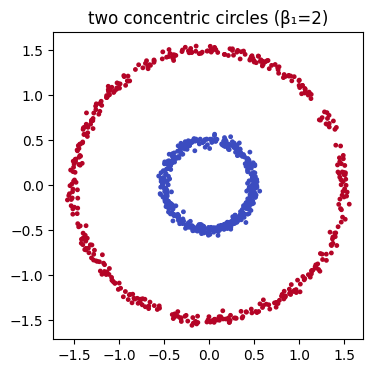

In [2]:
rng = np.random.default_rng(0)
n = 900
t = rng.uniform(0, 2*np.pi, n)
r = np.where(np.arange(n) < n//2, 0.5, 1.5) + 0.03*rng.standard_normal(n)
X = np.c_[r*np.cos(t), r*np.sin(t)].astype(np.float32)
y = (np.arange(n) >= n//2).astype(np.int64)
plt.figure(figsize=(4, 4)); plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=6)
plt.gca().set_aspect('equal'); plt.title('two concentric circles (β₁=2)'); plt.show()


## 2. Train a *wide* ReLU net to 100% accuracy

Faithful reproductions need a network that actually untangles the data — a wide MLP trained to (near-)zero error on the laptop GPU.


In [3]:
model = SmallMLP(input_dim=2, hidden_dims=[40, 40, 40, 40], output_dim=2)
train_briefly(model, X, y, X, y, epochs=300,
              aspects=['activations'], device=DEVICE, verbose=False)
print('train accuracy:', accuracy(model, X, y, device=DEVICE))
snap = extract_snapshot(model.to('cpu').eval(), X,
                        aspects=['activations'], layer_selection='all_linear')
layers = [X] + snap.all_activation_matrices()[:-1]   # input + hidden layers


train accuracy: 1.0


## 3. Per-layer persistent homology → Betti decreases with depth

We standardise each layer and run **Vietoris–Rips** PH, counting only the **persistent** `H1` loops (lifetime > ½ · max) — the robust Betti number the paper tracks.  (The paper's exact metric is graph-geodesic; VR on the standardised cloud gives the same simplification cleanly at this scale.)

*(Explicit extraction on purpose: this analysis needs the **input** layer prepended and each layer **standardised** — prep the model-first adapter can't express, unlike the activation/weight presets elsewhere.)*


In [4]:
# Standardise each layer so scale doesn't dominate the filtration.
layers_n = [(A - A.mean(0)) / (A.std(0) + 1e-9) for A in layers]
pipe = TDAPipeline.from_paper('naitzat2020', builder_kwargs__distance='euclidean')
results = pipe.fit(layers_n)         # list[TopoResult], one per layer

def persistent_b1(r, frac=0.5):
    d = r.diagram(1)
    if not len(d):
        return 0
    lt = d[:, 1] - d[:, 0]
    return int((lt > frac * lt.max()).sum())

b1 = [persistent_b1(r) for r in results]
for i, (r, b) in enumerate(zip(results, b1)):
    print(f'  layer {i}: persistent β1 = {b}   (raw H1 bars = {len(r.diagram(1))})')


  layer 0: persistent β1 = 2   (raw H1 bars = 117)
  layer 1: persistent β1 = 2   (raw H1 bars = 112)
  layer 2: persistent β1 = 1   (raw H1 bars = 145)
  layer 3: persistent β1 = 1   (raw H1 bars = 168)
  layer 4: persistent β1 = 1   (raw H1 bars = 173)


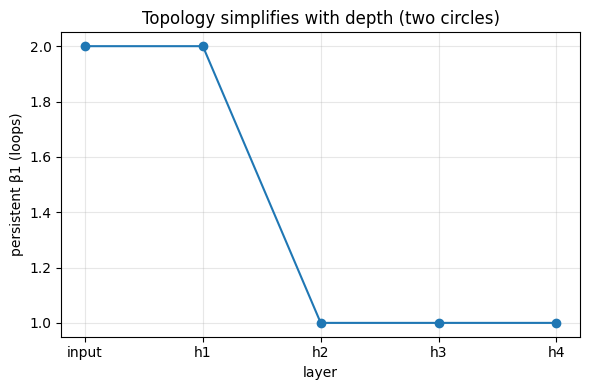

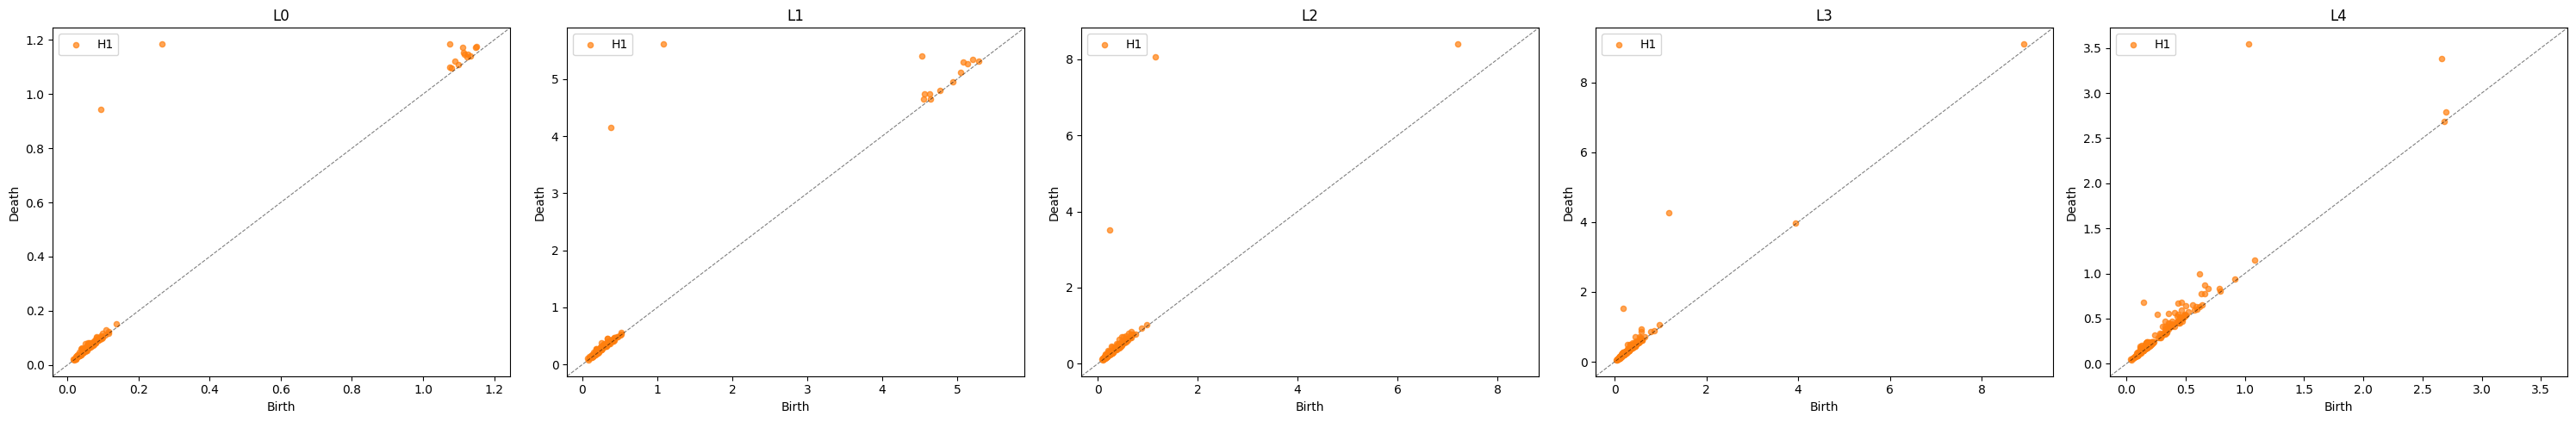

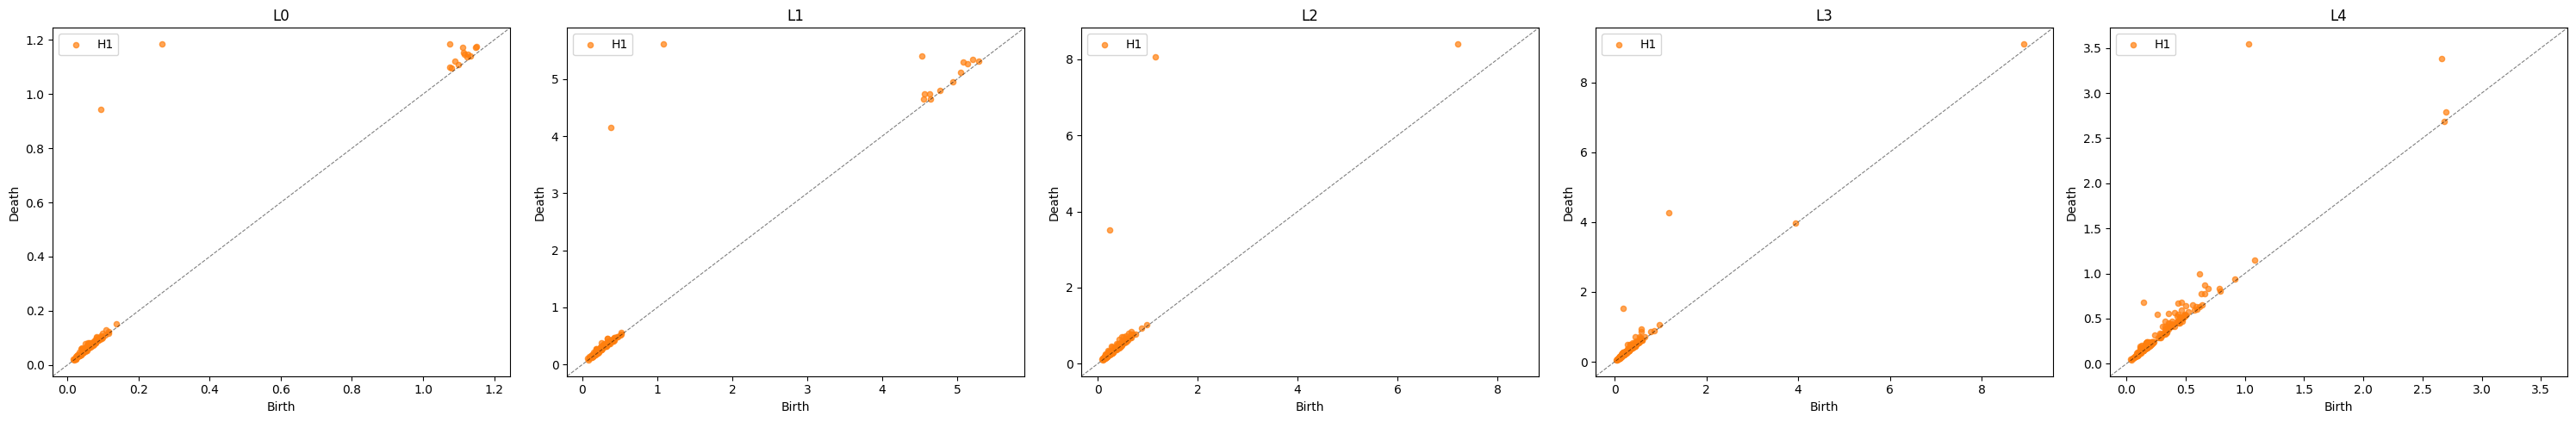

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(b1)), b1, 'o-')
plt.xticks(range(len(b1)), ['input'] + [f'h{i}' for i in range(1, len(b1))])
plt.ylabel('persistent β1 (loops)'); plt.xlabel('layer')
plt.title('Topology simplifies with depth (two circles)'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

from tanc.visualisation import plot_diagram_comparison
plot_diagram_comparison({f'L{i}': r.ph_result for i, r in enumerate(results)},
                        kind='diagram', dims=[1])


## Notes & gaps

* Implements the paper's signature result on **real activations** of a wide net trained to 100%: the input's **two loops** (β₁=2) are progressively simplified, ending at **one** deep in the net — Betti decreases with depth (their Fig. 11).
* The paper's exact filtration is graph-geodesic; we use standardised Vietoris–Rips, which gives the same simplification without the small-scale kNN-geodesic noise.  Counting *persistent* bars is what makes the trend robust.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
